# Ampere Analysis Notebook

This notebook demonstrates how to load HPL traces using the `ampere` library and visualize energy consumption.
Now running on **Arkouda** for scalable server-side processing.

In [271]:
from IPython.display import display
import re
import matplotlib.pyplot as plt
from ampere import Ensemble, Run, MetricConfig, MetricType, AmpereSession, Visualizer, Metric, connect
import arkouda as ak
import pandas as pd
import os
# Connect to Arkouda (registers cleanup automatically)
connect(server="localhost", port=5555)

/Users/hom/miniconda3/envs/ampere_dev/lib/python3.11/site-packages/arkouda/core/client.py:860: RuntimeWarning:

Version mismatch between client (2026.02.02+40.gec39a6ec8) and server (2026.02.02.1); this may cause some commands to fail or behave incorrectly! Updating arkouda is strongly recommended.

connected to arkouda server tcp://*:5555


Connecting to Arkouda server at localhost:5555...


In [272]:
TRACE="/Users/hom/Documents/ampere/examples/excursions-study/cycles-1"
os.system(f'cd {TRACE} && ~/otf2csv.py ./traces.otf2')

Converting trace at ./traces.otf2 to CSV...









Processing Process :   0%|          | 0/17191 [00:00<?, ?event/s]










Processing Process :   0%|          | 0/17191 [00:00<?, ?event/s]









Processing Process :   0%|          | 0/17191 [00:00<?, ?event/s]








Processing Process :   0%|          | 0/17191 [00:00<?, ?event/s]












Processing Process :   0%|          | 0/17191 [00:00<?, ?event/s]













Processing Process :   0%|          | 0/17191 [00:00<?, ?event/s]











Processing Process :   0%|          | 0/17191 [00:00<?, ?event/s]

















Processing Process Orphan thread 1:   0%|          | 0/14 [00:00<?, ?event/s]
















Processing Process Master thread:   0%|          | 0/4 [00:00<?, ?event/s]







Processing Process :   0%|          | 0/17191 [00:00<?, ?event/s]















Processing Process :   0%|          | 0/17191 [00:00<?, ?event/s]














Processing Process :   0%|          | 0/17191 [00:00<?, ?event/s]


















 ... (more hidden) ...

Proces


Reading completed in 2.50 seconds.
Writing completed in 0.01 seconds.
All done in 2.51 seconds (0.04 minutes).


0

In [273]:
# Define Metric Configs
configs = {
    re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
    re.compile(r".*rocm.*clk.*"): MetricConfig(MetricType.CUMULATIVE),
    # re.compile(r".*amd.*power.*"): MetricConfig(MetricType.INSTANTANEOUS, scale_factor=1e-6),
}

# Define Topology Resolver
def my_hpc_topology(metric_name, ranks):
    # if 'device=4' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0', 'MPI Rank 1']]
    # if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 2', 'MPI Rank 3']]
    # if 'device=6' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 4', 'MPI Rank 5']]
    # if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 6', 'MPI Rank 7']]
    # if 'device=0' in metric_name: return [r for r in ranks if r.name in ['Process']]
    # if 'device=2' in metric_name: return [r for r in ranks if r.name in ['Process']]
    # if 'device=4' in metric_name: return [r for r in ranks if r.name in ['Process']]
    # if 'device=6' in metric_name: return [r for r in ranks if r.name in ['Process']]
    return ranks

In [274]:
# ranks = [f"MPI Rank {i}" for i in range(8)]
ranks = ["Process"]
topo = {"Node0": ranks}

ensemble = Ensemble.from_trace_paths([TRACE], topo, configs)


print(ensemble.runs)

Loading Runs: 100%|██████████| 1/1 [00:00<00:00,  3.72it/s]

17254.626868009567


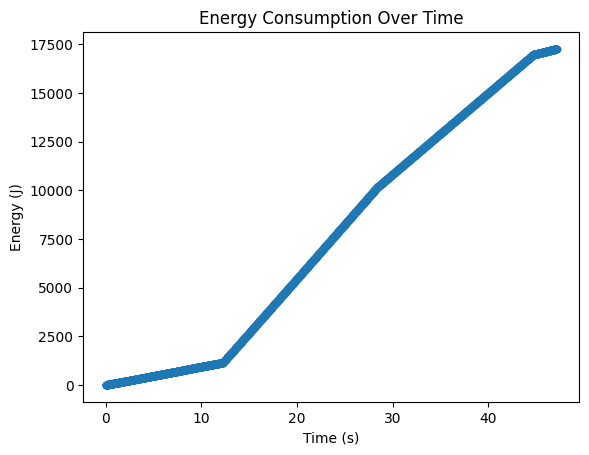

In [275]:
y = ensemble.runs[0].nodes[0].metrics["A2rocm_smi:::energy_count:device=0"]
df = pd.DataFrame({
    "Timestamp": y.times.tolist(),
    "Energy (J)": y.values.tolist()
})

initial_energy = df["Energy (J)"][0]
df["Energy (J)"] = df["Energy (J)"] - initial_energy
print(df["Energy (J)"].max())

df.plot.scatter(x="Timestamp", y="Energy (J)", title="Energy Consumption Over Time", xlabel="Time (s)", ylabel="Energy (J)")
plt.show()

In [276]:

# Derive instantaneous power from cumulative energy
def calc_power(energy_metric):
    t = energy_metric.times
    e = energy_metric.values
    dt = t[1:] - t[:-1]
    de = e[1:] - e[:-1]
    power = de / dt
    power = ak.where((power < 0) | (dt <= 0), 0.0, power)
    return Metric("power", t[1:], power, MetricConfig(MetricType.INSTANTANEOUS))

for d in [0, 2, 4, 6]:
    ensemble.add_derived_metric(
        f"A2rocm_smi:::inst_power:device={d}",
        calc_power,
        f"A2rocm_smi:::energy_count:device={d}"
    )

Deriving metric 'A2rocm_smi:::inst_power:device=0'...
Deriving metric 'A2rocm_smi:::inst_power:device=2'...
Deriving metric 'A2rocm_smi:::inst_power:device=4'...
Deriving metric 'A2rocm_smi:::inst_power:device=6'...


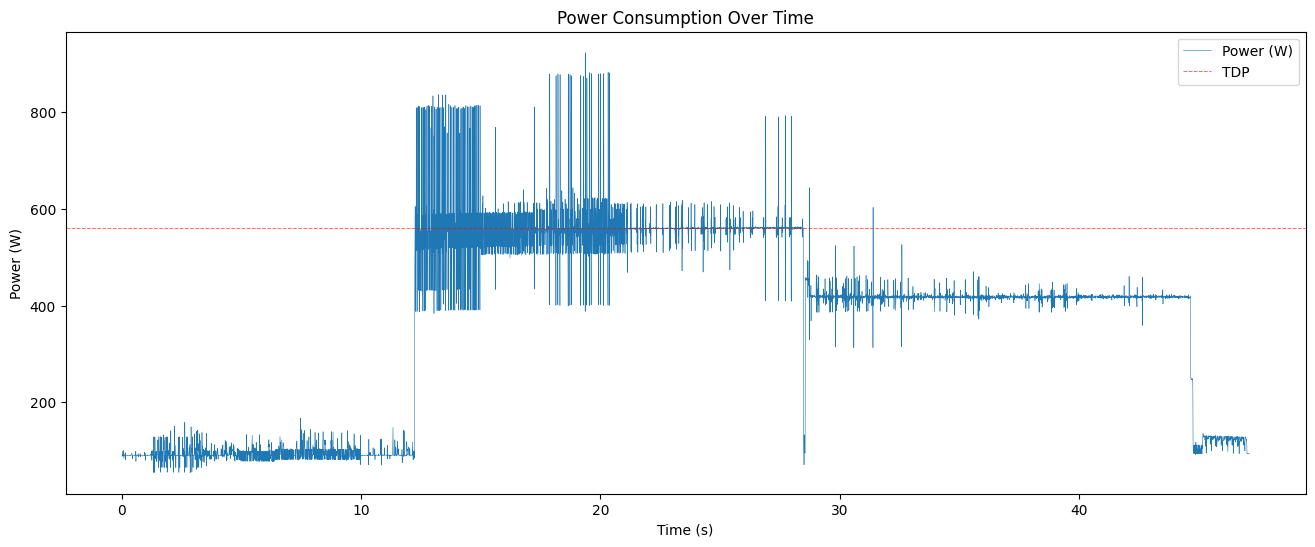

In [277]:
y = ensemble.runs[0].nodes[0].metrics["A2rocm_smi:::inst_power:device=0"]
df = pd.DataFrame({
    "Timestamp": y.times.tolist(),
    "Power (W)": y.values.tolist()
})
df.plot.line(x="Timestamp", y="Power (W)", title="Power Consumption Over Time", xlabel="Time (s)", ylabel="Power (W)", lw=0.4, figsize=(16, 6))
plt.axhline(560, color='red', linestyle='--', linewidth=0.7, alpha=0.6, label='TDP')
plt.legend()
plt.show()

Timestamp         0.302983
GFX Clock (Hz)    0.302983
dtype: float64


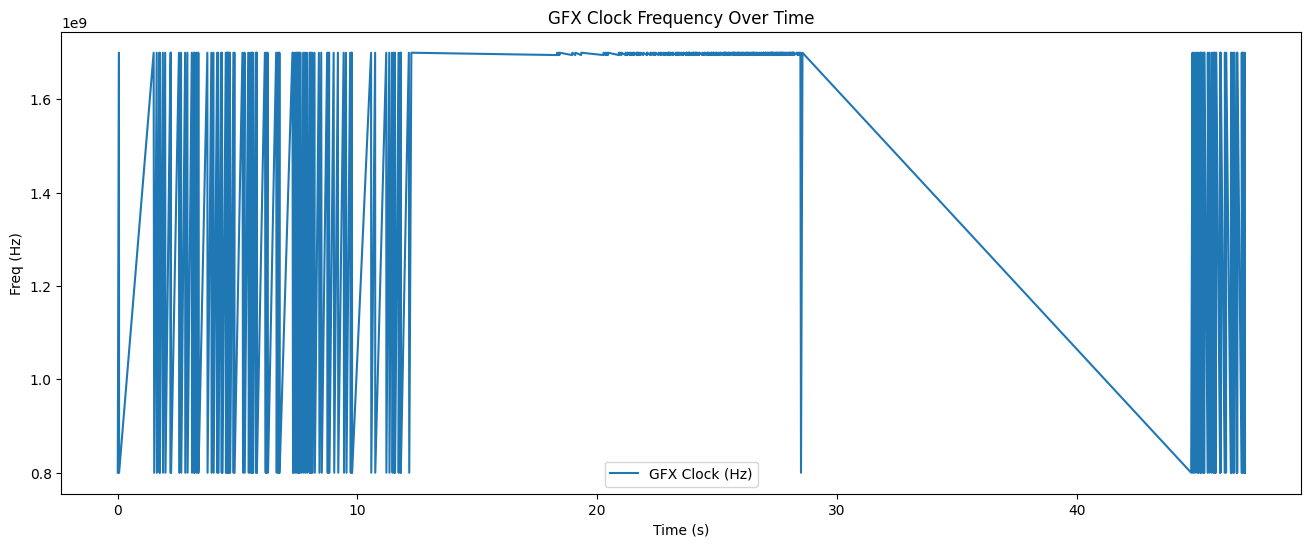

In [278]:
y = ensemble.runs[0].nodes[0].metrics["A2rocm_smi:::gpu_clk_freq_System:device=0:current"]
df = pd.DataFrame({
    "Timestamp": y.times.tolist(),
    "GFX Clock (Hz)": y.values.tolist()
})
print(df[(df["GFX Clock (Hz)"] < 1.7e9) & (df["GFX Clock (Hz)"] > 8e8)].count() / len(df["GFX Clock (Hz)"]))
df.plot.line(x="Timestamp", y="GFX Clock (Hz)", title="GFX Clock Frequency Over Time", xlabel="Time (s)", ylabel="Freq (Hz)", figsize=(16, 6))
plt.show()

In [279]:
df_joules = ak.DataFrame.concat([
    ensemble.attribute(
        metric,
        topology_resolver=my_hpc_topology,
        strategy='exclusive'
    ) for metric in ["A2rocm_smi:::energy_count:device=0", "A2rocm_smi:::energy_count:device=2", "A2rocm_smi:::energy_count:device=4", "A2rocm_smi:::energy_count:device=6"]
    # ) for metric in ["A2amd_smi:::energy_consumed:device=0",
    #                 "A2amd_smi:::energy_consumed:device=1",
    #                 "A2amd_smi:::energy_consumed:device=2",
    #                 "A2amd_smi:::energy_consumed:device=3"]
])
print("Attribution complete.")

Attributing 'A2rocm_smi:::energy_count:device=0' on Arkouda Server...


100%|██████████| 1/1 [00:00<00:00,  8.04it/s]


Attributing 'A2rocm_smi:::energy_count:device=2' on Arkouda Server...


100%|██████████| 1/1 [00:00<00:00,  8.32it/s]


Attributing 'A2rocm_smi:::energy_count:device=4' on Arkouda Server...


100%|██████████| 1/1 [00:00<00:00,  8.43it/s]


Attributing 'A2rocm_smi:::energy_count:device=6' on Arkouda Server...


100%|██████████| 1/1 [00:00<00:00,  8.60it/s]

Attribution complete.


In [280]:
# df_violations = ak.DataFrame.concat([
#     ensemble.attribute(
#         metric,
#         topology_resolver=my_hpc_topology,
#         strategy='exclusive'
#     # ) for metric in ["A2rocm_smi:::energy_count:device=0", "A2rocm_smi:::energy_count:device=2", "A2rocm_smi:::energy_count:device=4", "A2rocm_smi:::energy_count:device=6"]
#     ) for metric in ["A2amd_smi:::ppt_pwr_violation_acc:device=0",
#                     "A2amd_smi:::ppt_pwr_violation_acc:device=1",
#                     "A2amd_smi:::ppt_pwr_violation_acc:device=2",
#                     "A2amd_smi:::ppt_pwr_violation_acc:device=3"]
# ])
# print("Attribution complete.")

In [281]:
# display(df_violations.sort_values(by="Value", ascending=False).head(20).to_pandas())


In [282]:
display(df_joules.sort_values(by="Value", ascending=False).head(20).to_pandas())

,Start Time,End Time,Duration,Name,Depth,Value,Metadata,Rank,Node,Run
0,0.004283,45.168836,45.164554,main,1,17015.424672,{},Process,Node0,cycles-1
1,0.004283,45.168836,45.164554,main,1,16664.884809,{},Process,Node0,cycles-1
2,0.004283,45.168836,45.164554,main,1,16633.983503,{},Process,Node0,cycles-1
3,0.004283,45.168836,45.164554,main,1,16460.999536,{},Process,Node0,cycles-1


In [283]:

# display(df_rocblas_dgemm.to_pandas().head())

In [284]:
# Visualize Flamegraph for Rank 0
print("Generating Flamegraph...")
Visualizer.plot_flamegraph(
    df_joules, 
    rank_filter="MPI Rank 0", 
    metric_name="Joules"
)

Generating Flamegraph...
No data found for rank MPI Rank 0


In [285]:
# # Visualize Node View (Metrics + Flamegraphs)
# print("Generating Node View...")
# run = ensemble.runs[0]
# node_metrics = run.nodes[0].metrics
# metrics_to_plot = [m for name, m in node_metrics.items() if "violation" in name]

# Visualizer.plot_node_view(
#     attributed_df=df_violations,
#     ranks=["MPI Rank 0"],
#     metrics_data=metrics_to_plot,
#     title="Node 0 Analysis: Power Lines vs Function Execution"
# )

In [286]:
# 2. Get Average Power from Cumulative Energy Metric (using 'rate')
df_energy_rate = ak.DataFrame.concat([
    ensemble.attribute(
        metric,
        topology_resolver=my_hpc_topology,
        output_mode='rate',
        strategy='exclusive'
    ) for metric in ["A2rocm_smi:::energy_count:device=0", "A2rocm_smi:::energy_count:device=2", "A2rocm_smi:::energy_count:device=4", "A2rocm_smi:::energy_count:device=6"]
])
avg_energy_rate = df_energy_rate['Value'].mean()
print(f"Average Power (from Energy Metric): {avg_energy_rate:.2f} W")

Attributing 'A2rocm_smi:::energy_count:device=0' on Arkouda Server...


100%|██████████| 1/1 [00:00<00:00,  7.52it/s]


Attributing 'A2rocm_smi:::energy_count:device=2' on Arkouda Server...


100%|██████████| 1/1 [00:00<00:00,  7.60it/s]


Attributing 'A2rocm_smi:::energy_count:device=4' on Arkouda Server...


100%|██████████| 1/1 [00:00<00:00,  6.95it/s]


Attributing 'A2rocm_smi:::energy_count:device=6' on Arkouda Server...


100%|██████████| 1/1 [00:00<00:00,  8.18it/s]

Average Power (from Energy Metric): 369.62 W


In [287]:
# Visualize Distribution
Visualizer.plot_distribution(df_energy_rate, "Power Distribution (Device 0)", bins=50)

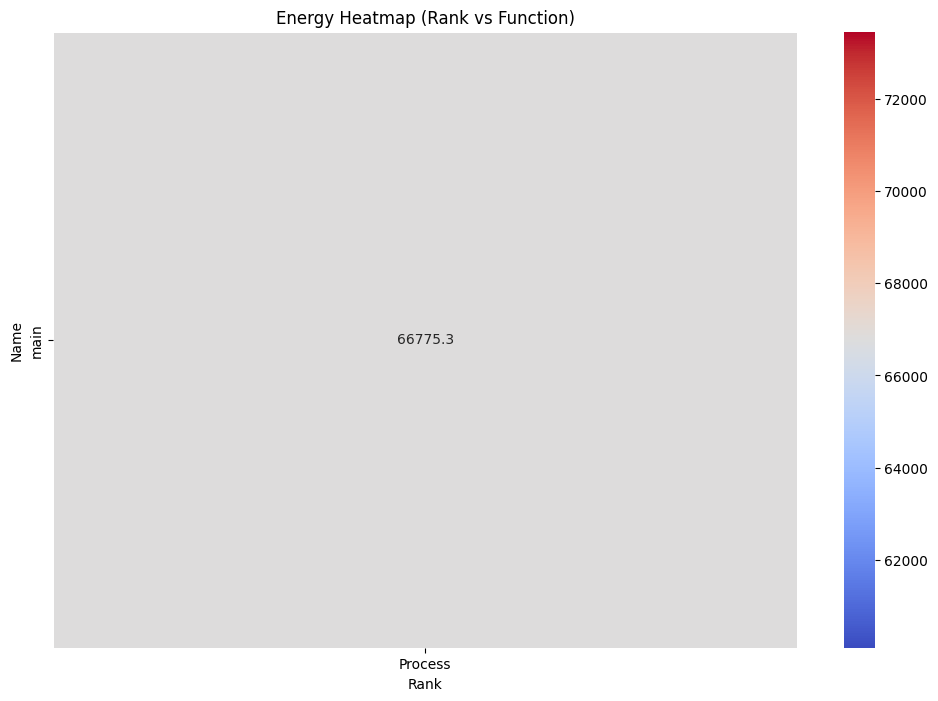

In [288]:
# Visualize Heatmap of Rates
Visualizer.plot_heatmap(df_joules, "Energy Heatmap (Rank vs Function)", cmap='coolwarm', top_n=24, aggregation_func='sum')

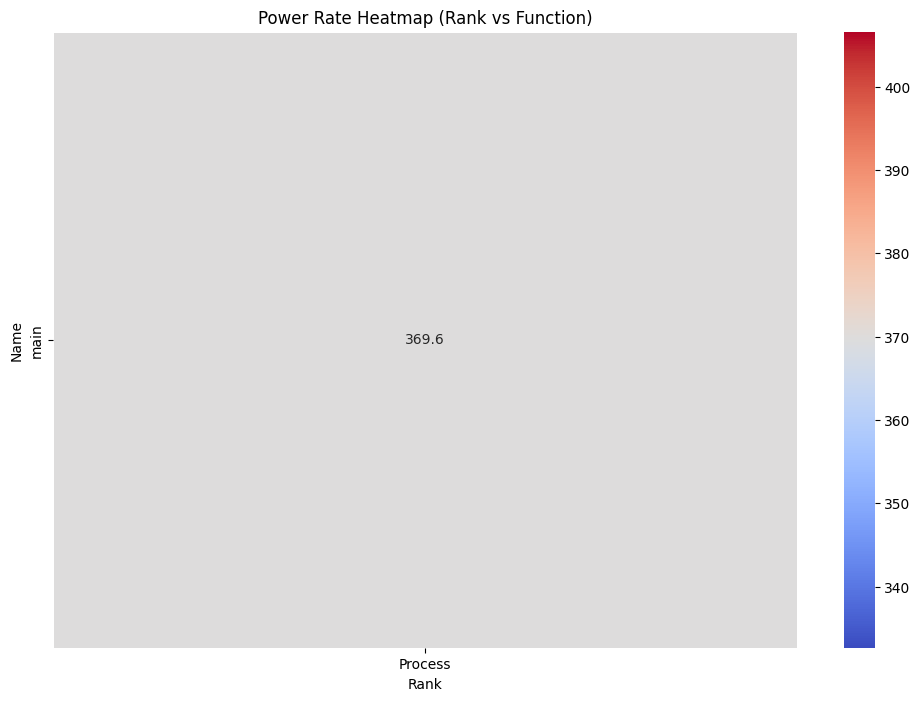

In [289]:
# Visualize Heatmap of Rates
Visualizer.plot_heatmap(df_energy_rate, "Power Rate Heatmap (Rank vs Function)", cmap='coolwarm', top_n=24, aggregation_func='mean')